In [3]:
import numpy as np
import pandas as pd

# Parameter für die Verteilungen
shape_weibull = 1.5  # Formparameter für Weibull-Verteilung
scale_weibull_base = 50  # Basis-Skalenparameter für Weibull-Verteilung (wird später individualisiert)
rate_censoring = 0.02  # Rate für Exponentialverteilung der Zensurierung

# Anzahl der Beobachtungen
n = 1000

# Generierung der Kovariaten
np.random.seed(42)
bmi = np.random.normal(25, 5, n)  # BMI zwischen ca. 15 und 35
blood_pressure = np.random.normal(120, 15, n)  # Systolischer Blutdruck zwischen ca. 90 und 150
cholesterol = np.random.normal(200, 30, n)  # Cholesterin zwischen ca. 140 und 260
diabetes = np.random.binomial(1, 0.2, n)  # Diabetesstatus: 0 = Nein, 1 = Ja

# Nicht-lineare Transformationen
bmi_squared = bmi ** 2
interaction_bmi_diabetes = bmi * diabetes

# Berechnung der Skalenfaktoren basierend auf den Kovariaten
lambda_weibull = scale_weibull_base * np.exp(
    0.05 * bmi - 
    0.01 * blood_pressure + 
    0.03 * cholesterol + 
    0.4 * diabetes +
    0.0002 * bmi_squared +  # Quadratische Beziehung für den BMI
    0.1 * interaction_bmi_diabetes  # Interaktion zwischen BMI und Diabetes
)

# Generierung der Ereigniszeiten basierend auf der Weibull-Verteilung
event_times = np.random.weibull(shape_weibull, n) * lambda_weibull


# Berechnung der Zensierungszeiten basierend auf der Exponentialverteilung
censoring_times = np.random.exponential(1 / rate_censoring, n)

# Bestimmung der beobachteten Zeiten und Ereignisindikatoren
observed_times = np.minimum(event_times, censoring_times)
event_occurred = event_times <= censoring_times

# Zusammenstellung des Datensatzes
data = pd.DataFrame({
    'BMI': bmi,
    'Blood_Pressure': blood_pressure,
    'Cholesterol': cholesterol,
    'Diabetes': diabetes,
    'BMI_Squared': bmi_squared,
    'Interaction_BMI_Diabetes': interaction_bmi_diabetes,
    'Observed_Time': observed_times,
    'Event_Occurred': event_occurred.astype(int)
})


data.head()




,BMI,Blood_Pressure,Cholesterol,Diabetes,BMI_Squared,Interaction_BMI_Diabetes,Observed_Time,Event_Occurred
0,27.483571,140.990332,179.744652,1,755.346662,27.483571,15.853320,0
1,24.308678,133.869505,195.664440,1,590.911850,24.308678,84.628964,0
2,28.238443,120.894456,176.227402,0,797.409646,0.000000,23.766136,0
3,32.615149,110.295948,190.761154,1,1063.747963,32.615149,4.627533,0
4,23.829233,130.473350,143.191560,0,567.832351,0.000000,20.944657,0


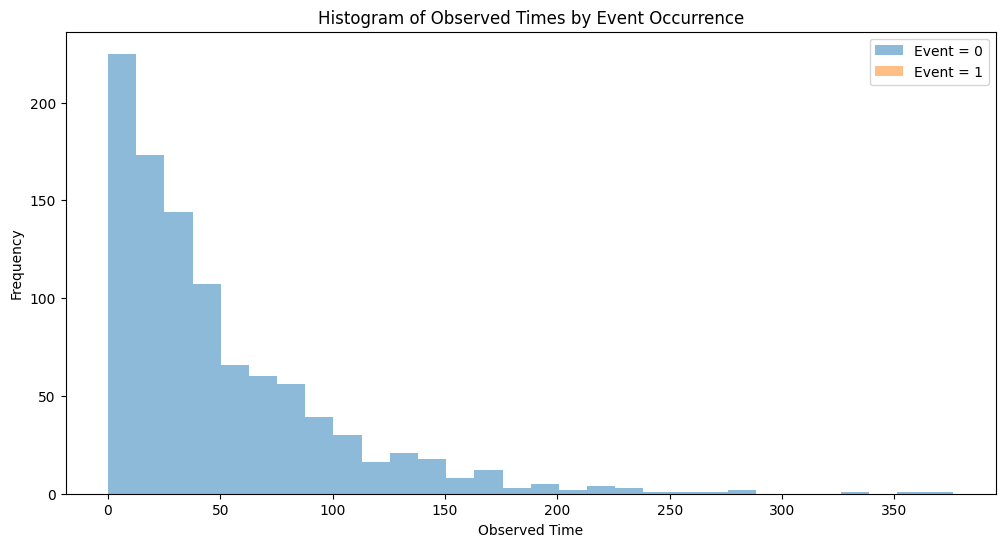

In [4]:
import matplotlib.pyplot as plt

# Histogramm der Ereigniszeiten für Event = 0 und Event = 1
plt.figure(figsize=(12, 6))

# Histogramm für Event = 0
plt.hist(data[data['Event_Occurred'] == 0]['Observed_Time'], bins=30, alpha=0.5, label='Event = 0')

# Histogramm für Event = 1
plt.hist(data[data['Event_Occurred'] == 1]['Observed_Time'], bins=30, alpha=0.5, label='Event = 1')

plt.xlabel('Observed Time')
plt.ylabel('Frequency')
plt.title('Histogram of Observed Times by Event Occurrence')
plt.legend(loc='upper right')

plt.show()
